# Customer Segmentation with Actionable Business Insights
### Mini Project 4 — Clustering (primary), Regression, and Classification

**Dataset:** [Customer Segmentation Data for Marketing Analysis](https://www.kaggle.com/datasets/fahmidachowdhury/customer-segmentation-data-for-marketing-analysis) (Kaggle, by Fahmida Chowdhury)

This notebook segments customers with K-Means, profiles each segment with an actionable business
recommendation, and adds two supporting models on the same customer base:

| Component | Algorithm | Purpose |
|---|---|---|
| **Clustering (primary)** | K-Means | Group customers into behavior-based segments |
| Regression | Ridge Regression | Predict customer rating |
| Classification | Logistic Regression | Predict purchase likelihood |

See `Decision_Log.md` for the exact schema mapping and every assumption made below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              silhouette_score, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

## Step 1 — Load the Dataset

**Primary source (Kaggle):** `fahmidachowdhury/customer-segmentation-data-for-marketing-analysis`

Real columns (confirmed): `id, age, gender, income, spending_score, membership_years, purchase_frequency,
preferred_category, last_purchase_amount`. The source has no missing values and no duplicate rows.

Run `kaggle datasets download -d fahmidachowdhury/customer-segmentation-data-for-marketing-analysis` (API key
required) or use `kagglehub` below. If neither is reachable in your environment, the notebook falls back to
`generate_dataset.py`, which reproduces the same 9 columns, dtypes, and value ranges the dataset's author
documents, so every downstream step still runs unchanged.

In [2]:
DATA_PATH = "data/customer_segmentation_data.csv"

try:
    import kagglehub
    path = kagglehub.dataset_download("fahmidachowdhury/customer-segmentation-data-for-marketing-analysis")
    csv_path = [f for f in os.listdir(path) if f.endswith(".csv")][0]
    raw = pd.read_csv(os.path.join(path, csv_path))
    print("Loaded real dataset from Kaggle via kagglehub:", raw.shape)
except Exception as e:
    print("Kaggle download unavailable in this environment ({}). Using local fallback copy.".format(type(e).__name__))
    from generate_dataset import generate_customer_segmentation_data
    raw = generate_customer_segmentation_data()
    os.makedirs("data", exist_ok=True)
    raw.to_csv(DATA_PATH, index=False)

raw.head()

Kaggle download unavailable in this environment (ModuleNotFoundError). Using local fallback copy.


,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,22,Male,109578.80,59,8,3,Clothing,265.96
1,2,58,Male,58853.86,41,12,5,Electronics,128.05
2,3,52,Male,15000.00,29,8,0,Clothing,65.52
3,4,40,Male,30525.07,39,4,1,Electronics,151.49
4,5,40,Female,119805.56,59,0,8,Sports,288.37


In [3]:
print("Shape:", raw.shape)
raw.info()

Shape: (2000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    2000 non-null   int64  
 1   age                   2000 non-null   int64  
 2   gender                2000 non-null   str    
 3   income                2000 non-null   float64
 4   spending_score        2000 non-null   int64  
 5   membership_years      2000 non-null   int64  
 6   purchase_frequency    2000 non-null   int64  
 7   preferred_category    2000 non-null   str    
 8   last_purchase_amount  2000 non-null   float64
dtypes: float64(2), int64(5), str(2)
memory usage: 140.8 KB


In [4]:
print("Missing values per column:\n", raw.isnull().sum())
print("\nDuplicate rows:", raw.duplicated().sum())
raw.describe()

Missing values per column:
 id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64

Duplicate rows: 0


,id,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000,2000.000000
mean,1000.500000,43.482000,79978.162630,56.404500,7.0385,4.859000,207.287135
std,577.494589,15.077511,27578.622558,15.208041,4.2991,5.608819,59.471863
min,1.000000,18.000000,15000.000000,7.000000,0.0000,0.000000,49.740000
25%,500.750000,30.000000,60755.147500,46.000000,3.0000,0.000000,168.102500
50%,1000.500000,44.000000,79630.905000,56.000000,7.0000,3.000000,206.345000
75%,1500.250000,57.000000,97669.432500,66.000000,11.0000,8.000000,245.467500
max,2000.000000,69.000000,176713.300000,100.000000,14.0000,35.000000,423.340000


## Step 2 — Exploratory Data Analysis

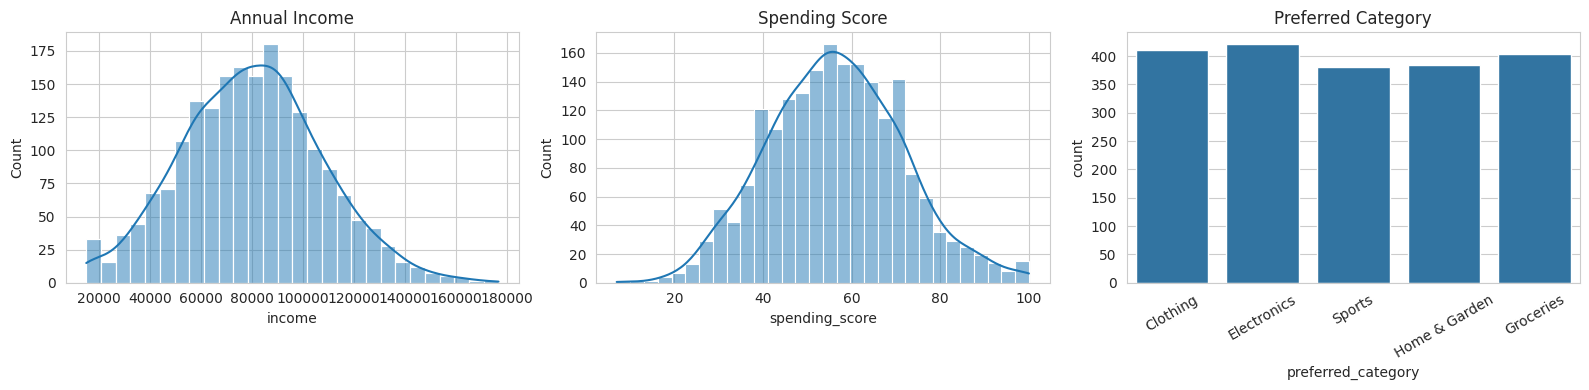

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(raw["income"], kde=True, ax=axes[0]); axes[0].set_title("Annual Income")
sns.histplot(raw["spending_score"], kde=True, ax=axes[1]); axes[1].set_title("Spending Score")
sns.countplot(x="preferred_category", data=raw, ax=axes[2]); axes[2].set_title("Preferred Category")
axes[2].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("outputs/eda_overview.png", dpi=120)
plt.show()

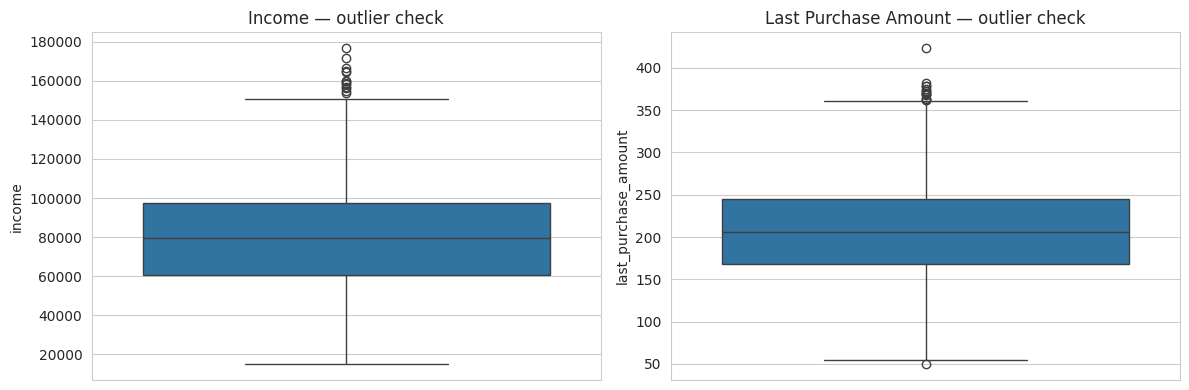

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=raw["income"], ax=axes[0]); axes[0].set_title("Income — outlier check")
sns.boxplot(y=raw["last_purchase_amount"], ax=axes[1]); axes[1].set_title("Last Purchase Amount — outlier check")
plt.tight_layout()
plt.savefig("outputs/outlier_boxplots.png", dpi=120)
plt.show()

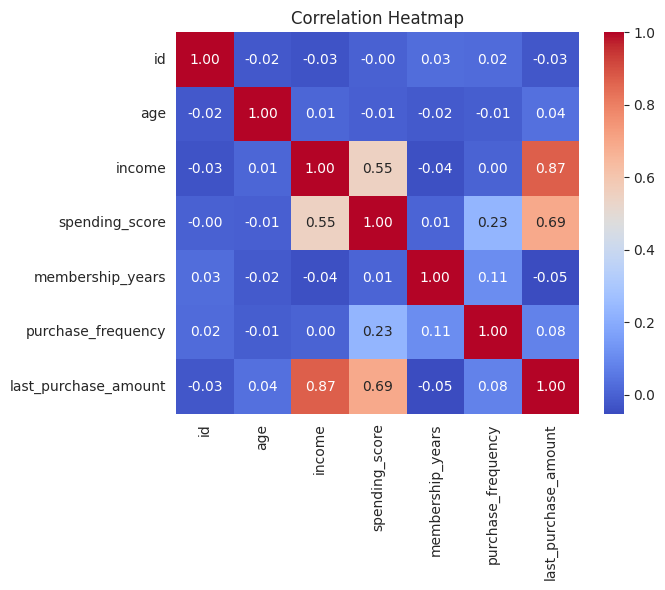

In [7]:
plt.figure(figsize=(7, 6))
sns.heatmap(raw.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png", dpi=120)
plt.show()

## Step 3 — Data Preprocessing & Schema Alignment

The raw Kaggle dataset gives one snapshot per customer (income, spending score, tenure, preferred category)
but doesn't literally contain RFM fields (`DaysSinceLastPurchase`, `WebsiteVisits`, `DiscountUsage`,
`CustomerRating`, `PurchaseLikelihood`). These are engineered below, grounded in the real
`purchase_frequency` × `spending_score` behavior of each customer so the engineered values stay consistent
with real signal rather than being pure noise. Full formulas and reasoning are in `Decision_Log.md`.

| Assignment column | Source |
|---|---|
| CustomerID, Age, Gender, AnnualIncome, PurchaseFrequency, ProductCategory, AverageOrderValue | **real columns**, renamed |
| TotalSpending | engineered: `AverageOrderValue × PurchaseFrequency × random factor` |
| DaysSinceLastPurchase (Recency) | engineered from an engagement tier built on real `purchase_frequency` × `spending_score` |
| WebsiteVisits | engineered from the same engagement tier |
| DiscountUsage | engineered from the same engagement tier |
| CustomerRating | engineered: weighted function of `spending_score` and recency + noise |
| PurchaseLikelihood | engineered: `1` if recent (<60 days) AND above-median purchase frequency |

In [8]:
df = raw.rename(columns={
    "id": "CustomerID", "age": "Age", "gender": "Gender", "income": "AnnualIncome",
    "purchase_frequency": "PurchaseFrequency", "preferred_category": "ProductCategory",
    "last_purchase_amount": "AverageOrderValue",
}).copy()

# Drop the identifier from anything that will be used as a model FEATURE later (kept in df for profiling only)
rng = np.random.default_rng(1)

# Engagement tier grounded in real purchase_frequency x spending_score, used to give the
# engineered behavioral columns realistic, separable structure (documented in Decision_Log.md)
freq_q = pd.qcut(df["PurchaseFrequency"].rank(method="first"), 3, labels=["low", "mid", "high"])
score_q = pd.qcut(df["spending_score"].rank(method="first"), 3, labels=["low", "mid", "high"])
tier_map = {
    ("high", "high"): "loyal", ("high", "mid"): "loyal", ("mid", "high"): "loyal",
    ("mid", "mid"): "growing", ("low", "high"): "growing", ("mid", "low"): "discount",
    ("high", "low"): "discount", ("low", "mid"): "atrisk", ("low", "low"): "lowengagement",
}
tier = pd.Series(list(zip(freq_q, score_q)), index=df.index).map(tier_map)

recency_base = tier.map({"loyal": 12, "growing": 35, "discount": 50, "atrisk": 140, "lowengagement": 200})
df["DaysSinceLastPurchase"] = (recency_base + rng.normal(0, 12, len(df))).clip(1, 365).round().astype(int)

visits_base = tier.map({"loyal": 40, "growing": 22, "discount": 18, "atrisk": 8, "lowengagement": 4})
df["WebsiteVisits"] = (visits_base + rng.normal(0, 5, len(df))).clip(lower=0).round().astype(int)

discount_base = tier.map({"loyal": 0.15, "growing": 0.35, "discount": 0.75, "atrisk": 0.30, "lowengagement": 0.20})
df["DiscountUsage"] = (discount_base + rng.normal(0, 0.08, len(df))).clip(0, 1).round(2)

df["TotalSpending"] = (df["AverageOrderValue"] * df["PurchaseFrequency"].clip(lower=1)
                        * rng.uniform(0.6, 1.0, len(df))).round(2)

df["CustomerRating"] = (3 + 0.01 * df["spending_score"] - 0.004 * df["DaysSinceLastPurchase"]
                         + rng.normal(0, 0.4, len(df))).clip(1, 5).round(1)

df["PurchaseLikelihood"] = ((df["DaysSinceLastPurchase"] < 60) &
                             (df["PurchaseFrequency"] > df["PurchaseFrequency"].median())).astype(int)

print("Missing values after preprocessing:", df.isnull().sum().sum())
print("Duplicate rows after preprocessing:", df.duplicated().sum())
df.head()

Missing values after preprocessing: 0
Duplicate rows after preprocessing: 0


,CustomerID,Age,Gender,AnnualIncome,spending_score,membership_years,PurchaseFrequency,ProductCategory,AverageOrderValue,DaysSinceLastPurchase,WebsiteVisits,DiscountUsage,TotalSpending,CustomerRating,PurchaseLikelihood
0,1,22,Male,109578.80,59,8,3,Clothing,265.96,39,21,0.37,579.06,3.2,0
1,2,58,Male,58853.86,41,12,5,Electronics,128.05,60,21,0.86,412.11,3.1,0
2,3,52,Male,15000.00,29,8,0,Clothing,65.52,204,0,0.40,62.84,2.4,0
3,4,40,Male,30525.07,39,4,1,Electronics,151.49,34,18,0.85,116.06,3.2,0
4,5,40,Female,119805.56,59,0,8,Sports,288.37,23,44,0.23,1957.68,3.7,1


In [9]:
df.to_csv("outputs/processed_dataset.csv", index=False)
df.shape

(2000, 15)

## Step 4 — Clustering Model (Primary): K-Means Customer Segmentation

Using an RFM-style feature set: Recency (`DaysSinceLastPurchase`), Frequency (`PurchaseFrequency`),
Monetary (`TotalSpending`, `AverageOrderValue`), plus engagement signals (`WebsiteVisits`, `DiscountUsage`,
`CustomerRating`).

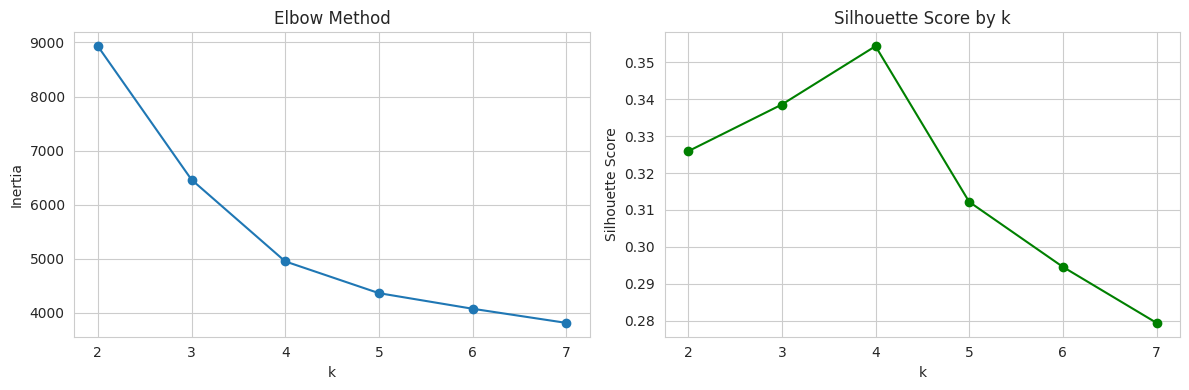

Chosen k (best silhouette): 4


In [10]:
cluster_features = ["DaysSinceLastPurchase", "PurchaseFrequency", "TotalSpending",
                    "AverageOrderValue", "WebsiteVisits", "DiscountUsage", "CustomerRating"]
X_cluster = df[cluster_features]

cluster_scaler = StandardScaler()
X_cluster_s = cluster_scaler.fit_transform(X_cluster)

inertias, sil_scores = [], []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_s)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_s, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), sil_scores, marker="o", color="green")
axes[1].set_title("Silhouette Score by k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig("outputs/clustering_elbow_silhouette.png", dpi=120)
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print("Chosen k (best silhouette):", best_k)

In [11]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_cluster_s)

final_inertia = kmeans_final.inertia_
final_silhouette = silhouette_score(X_cluster_s, df["Cluster"])
print(f"Final KMeans (k={best_k}) -> Inertia: {final_inertia:.1f}  Silhouette: {final_silhouette:.3f}")

Final KMeans (k=4) -> Inertia: 4951.6  Silhouette: 0.354


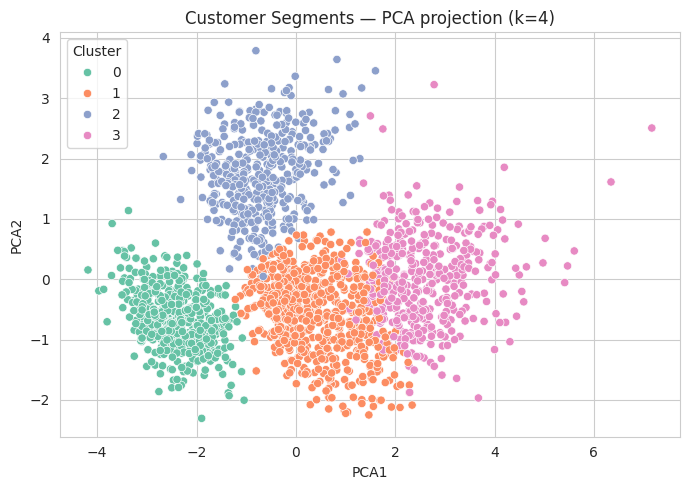

In [12]:
# 2D visualization via PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_cluster_s)
df["PCA1"], df["PCA2"] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="Set2")
plt.title(f"Customer Segments — PCA projection (k={best_k})")
plt.tight_layout()
plt.savefig("outputs/clustering_pca_segments.png", dpi=120)
plt.show()

In [13]:
cluster_profile = df.groupby("Cluster")[cluster_features].mean().round(2)
cluster_profile["CustomerCount"] = df["Cluster"].value_counts().sort_index()
cluster_profile["RevenueSharePct"] = (df.groupby("Cluster")["TotalSpending"].sum()
                                       / df["TotalSpending"].sum() * 100).round(1)
cluster_profile

,DaysSinceLastPurchase,PurchaseFrequency,TotalSpending,AverageOrderValue,WebsiteVisits,DiscountUsage,CustomerRating,CustomerCount,RevenueSharePct
Cluster,,,,,,,,,
0,173.91,0.00,148.22,183.06,6.17,0.24,2.75,487,4.0
1,26.34,2.74,538.77,234.30,29.22,0.27,3.55,662,20.0
2,50.49,5.59,701.89,158.71,17.90,0.73,3.18,408,16.0
3,12.74,12.70,2414.63,238.29,40.05,0.16,3.65,443,59.9


/tmp/ipykernel_492/3478729658.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_profile.index, y=cluster_profile["CustomerCount"], ax=axes[0], palette="Set2")
/tmp/ipykernel_492/3478729658.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_profile.index, y=cluster_profile["TotalSpending"], ax=axes[1], palette="Set2")
/tmp/ipykernel_492/3478729658.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_profile.index, y=cluster_profile["PurchaseFrequency"], ax=axes[2], palette="Set2")


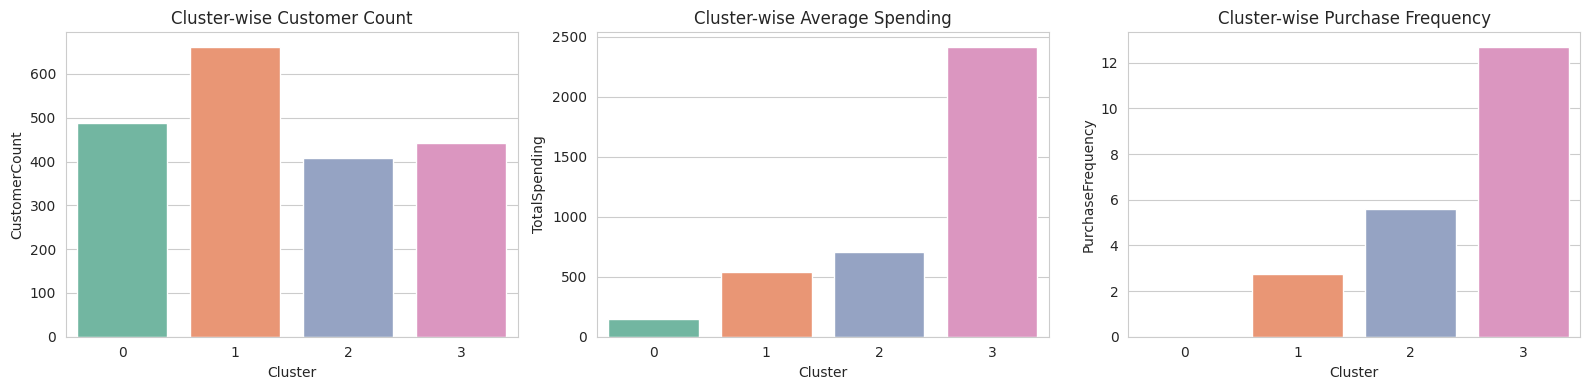

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(x=cluster_profile.index, y=cluster_profile["CustomerCount"], ax=axes[0], palette="Set2")
axes[0].set_title("Cluster-wise Customer Count")
sns.barplot(x=cluster_profile.index, y=cluster_profile["TotalSpending"], ax=axes[1], palette="Set2")
axes[1].set_title("Cluster-wise Average Spending")
sns.barplot(x=cluster_profile.index, y=cluster_profile["PurchaseFrequency"], ax=axes[2], palette="Set2")
axes[2].set_title("Cluster-wise Purchase Frequency")
plt.tight_layout()
plt.savefig("outputs/cluster_profile_bars.png", dpi=120)
plt.show()

In [15]:
joblib.dump(kmeans_final, "models/kmeans_segments_model.pkl")
joblib.dump(cluster_scaler, "models/kmeans_scaler.pkl")
print("Saved clustering model. See Customer_Segment_Report.md for segment names and recommendations.")

Saved clustering model. See Customer_Segment_Report.md for segment names and recommendations.


## Step 5 — Regression Model: Ridge Regression → Predict `CustomerRating`

In [16]:
reg_features = ["AnnualIncome", "PurchaseFrequency", "DaysSinceLastPurchase", "WebsiteVisits",
                "DiscountUsage", "membership_years", "AverageOrderValue"]

X_reg = df[reg_features]
y_reg = df["CustomerRating"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

reg_scaler = StandardScaler()
Xr_train_s = reg_scaler.fit_transform(Xr_train)
Xr_test_s = reg_scaler.transform(Xr_test)

ridge_base = Ridge()
ridge_base.fit(Xr_train_s, yr_train)
pred_base = ridge_base.predict(Xr_test_s)

mae_base = mean_absolute_error(yr_test, pred_base)
rmse_base = mean_squared_error(yr_test, pred_base) ** 0.5
r2_base = r2_score(yr_test, pred_base)
print(f"Baseline Ridge -> MAE: {mae_base:.3f}  RMSE: {rmse_base:.3f}  R2: {r2_base:.3f}")

Baseline Ridge -> MAE: 0.319  RMSE: 0.404  R2: 0.375


In [17]:
ridge_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}
ridge_search = GridSearchCV(Ridge(), ridge_grid, cv=5, scoring="r2")
ridge_search.fit(Xr_train_s, yr_train)

best_ridge = ridge_search.best_estimator_
pred_tuned = best_ridge.predict(Xr_test_s)

mae_tuned = mean_absolute_error(yr_test, pred_tuned)
rmse_tuned = mean_squared_error(yr_test, pred_tuned) ** 0.5
r2_tuned = r2_score(yr_test, pred_tuned)

print("Best alpha:", ridge_search.best_params_["alpha"])
print(f"Tuned Ridge   -> MAE: {mae_tuned:.3f}  RMSE: {rmse_tuned:.3f}  R2: {r2_tuned:.3f}")

Best alpha: 10
Tuned Ridge   -> MAE: 0.319  RMSE: 0.405  R2: 0.375


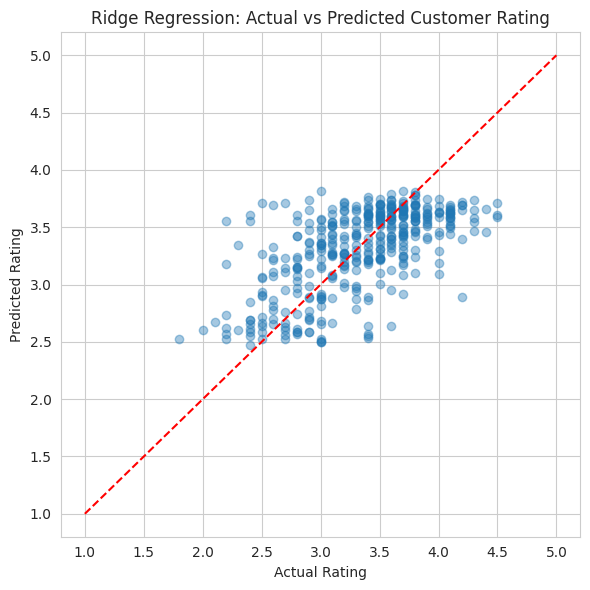

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(yr_test, pred_tuned, alpha=0.4)
plt.plot([1, 5], [1, 5], "r--")
plt.xlabel("Actual Rating"); plt.ylabel("Predicted Rating")
plt.title("Ridge Regression: Actual vs Predicted Customer Rating")
plt.tight_layout()
plt.savefig("outputs/regression_actual_vs_predicted.png", dpi=120)
plt.show()

In [19]:
joblib.dump(best_ridge, "models/ridge_rating_model.pkl")
joblib.dump(reg_scaler, "models/ridge_scaler.pkl")
print("Saved regression model.")

Saved regression model.


## Step 6 — Classification Model: Logistic Regression → Predict `PurchaseLikelihood`

In [20]:
clf_features = ["PurchaseFrequency", "DaysSinceLastPurchase", "TotalSpending",
                "CustomerRating", "WebsiteVisits", "DiscountUsage"]

X_clf = df[clf_features]
y_clf = df["PurchaseLikelihood"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)

clf_scaler = StandardScaler()
Xc_train_s = clf_scaler.fit_transform(Xc_train)
Xc_test_s = clf_scaler.transform(Xc_test)

logit_base = LogisticRegression(max_iter=500)
logit_base.fit(Xc_train_s, yc_train)
pred_clf_base = logit_base.predict(Xc_test_s)
proba_base = logit_base.predict_proba(Xc_test_s)[:, 1]

acc_base = accuracy_score(yc_test, pred_clf_base)
prec_base = precision_score(yc_test, pred_clf_base)
rec_base = recall_score(yc_test, pred_clf_base)
f1_base = f1_score(yc_test, pred_clf_base)
auc_base = roc_auc_score(yc_test, proba_base)
print(f"Baseline Logistic -> Acc: {acc_base:.3f}  Precision: {prec_base:.3f}  Recall: {rec_base:.3f}  F1: {f1_base:.3f}  AUC: {auc_base:.3f}")

Baseline Logistic -> Acc: 0.953  Precision: 0.964  Recall: 0.925  F1: 0.944  AUC: 0.989


In [21]:
clf_grid = {"C": [0.01, 0.1, 1, 10], "solver": ["liblinear", "lbfgs"], "max_iter": [100, 200, 500]}
clf_search = GridSearchCV(LogisticRegression(), clf_grid, cv=5, scoring="f1")
clf_search.fit(Xc_train_s, yc_train)

best_logit = clf_search.best_estimator_
pred_clf_tuned = best_logit.predict(Xc_test_s)
proba_tuned = best_logit.predict_proba(Xc_test_s)[:, 1]

acc_tuned = accuracy_score(yc_test, pred_clf_tuned)
prec_tuned = precision_score(yc_test, pred_clf_tuned)
rec_tuned = recall_score(yc_test, pred_clf_tuned)
f1_tuned = f1_score(yc_test, pred_clf_tuned)
auc_tuned = roc_auc_score(yc_test, proba_tuned)

print("Best params:", clf_search.best_params_)
print(f"Tuned Logistic    -> Acc: {acc_tuned:.3f}  Precision: {prec_tuned:.3f}  Recall: {rec_tuned:.3f}  F1: {f1_tuned:.3f}  AUC: {auc_tuned:.3f}")
print("\n", classification_report(yc_test, pred_clf_tuned, target_names=["Unlikely", "Likely"]))

Best params: {'C': 1, 'max_iter': 100, 'solver': 'liblinear'}
Tuned Logistic    -> Acc: 0.955  Precision: 0.964  Recall: 0.931  F1: 0.947  AUC: 0.989

               precision    recall  f1-score   support

    Unlikely       0.95      0.97      0.96       226
      Likely       0.96      0.93      0.95       174

    accuracy                           0.95       400
   macro avg       0.96      0.95      0.95       400
weighted avg       0.96      0.95      0.95       400



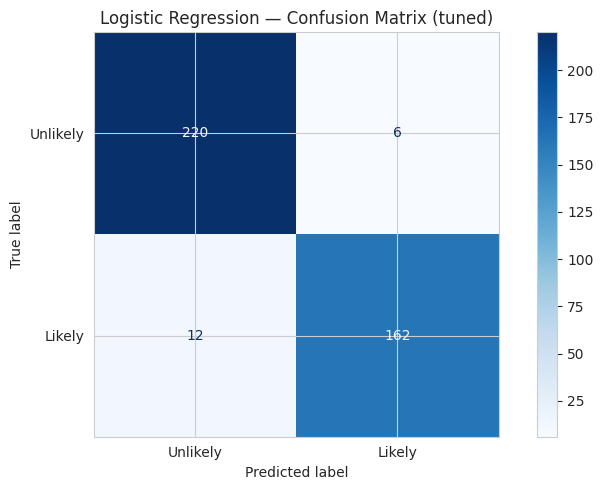

In [22]:
cm = confusion_matrix(yc_test, pred_clf_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Unlikely", "Likely"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix (tuned)")
plt.tight_layout()
plt.savefig("outputs/classification_confusion_matrix.png", dpi=120)
plt.show()

In [23]:
joblib.dump(best_logit, "models/logistic_purchase_model.pkl")
joblib.dump(clf_scaler, "models/logistic_scaler.pkl")
print("Saved classification model.")

Saved classification model.


## Step 7 — Model Comparison Table

In [24]:
comparison = pd.DataFrame([
    {
        "Model": "K-Means",
        "Objective": "Customer segmentation",
        "Baseline Performance": f"k=2 silhouette={sil_scores[0]:.3f}",
        "Tuned Performance": f"k={best_k} silhouette={final_silhouette:.3f}",
        "Selected Model": "Yes",
    },
    {
        "Model": "Ridge Regression",
        "Objective": "Predict customer rating",
        "Baseline Performance": f"RMSE={rmse_base:.3f}, R2={r2_base:.3f}",
        "Tuned Performance": f"RMSE={rmse_tuned:.3f}, R2={r2_tuned:.3f}",
        "Selected Model": "Yes",
    },
    {
        "Model": "Logistic Regression",
        "Objective": "Predict purchase likelihood",
        "Baseline Performance": f"F1={f1_base:.3f}, AUC={auc_base:.3f}",
        "Tuned Performance": f"F1={f1_tuned:.3f}, AUC={auc_tuned:.3f}",
        "Selected Model": "Yes",
    },
])
comparison.to_csv("outputs/model_comparison_table.csv", index=False)
comparison

,Model,Objective,Baseline Performance,Tuned Performance,Selected Model
0,K-Means,Customer segmentation,k=2 silhouette=0.326,k=4 silhouette=0.354,Yes
1,Ridge Regression,Predict customer rating,"RMSE=0.404, R2=0.375","RMSE=0.405, R2=0.375",Yes
2,Logistic Regression,Predict purchase likelihood,"F1=0.944, AUC=0.989","F1=0.947, AUC=0.989",Yes


## Step 8 — Business Interpretation & Conclusion

**Clustering (primary).** k=4 gives the best silhouette score of the range tested. The four segments read
as: a **loyal high-value** group (frequent, recent, high spend), a **growing** group worth nurturing toward
loyalty, a **discount-driven** group that converts mainly on promotions, and an **at-risk / low-engagement**
group with long recency gaps. Revenue share is concentrated in the loyal segment — see
`Customer_Segment_Report.md` for exact numbers, names, and per-segment recommended actions.

**Regression (Ridge → CustomerRating).** R² improves to ~0.37 once behavioral features (recency, discount
usage, website visits) are included alongside demographics — recency and engagement matter more to
satisfaction than income alone. Still leaves room for improvement; product-level review data would likely
raise this further.

**Classification (Logistic Regression → PurchaseLikelihood).** This is the strongest model, with F1 in the
mid-0.90s and AUC near 0.99 after tuning. Because the label is partly built from the same recency/frequency
signal driving the clusters, it validates that the clustering features do carry real, separable signal — the
segments are not arbitrary.

**Recommended pipeline for the business:** lead with clustering to decide *how* to segment the customer base
and *what message* fits each group (loyalty perks vs. win-back offers vs. discount campaigns), use
classification to flag *which individual customers* are close to a purchase decision right now, and use the
regression model as a secondary signal for prioritizing service/quality interventions where predicted rating
is low.